In [ ]:
import pandas as pd

# Path to your MAF file
maf_file = "data/mc3.v0.2.8.PUBLIC_segmeans_purity_cohort_gender.maf"

# Read the MAF file into a DataFrame.
# The 'comment' parameter skips any header lines that start with '#' (if present)
df = pd.read_csv(maf_file, sep="\t", comment="#", low_memory=False)

# Display the first few rows of the DataFrame
print(df.head())

In [ ]:
import pickle as pkl

# Save the DataFrame to a pickle file
pkl.dump(df, open("data/mc3.pkl", "wb"))

In [1]:
import pandas as pd
import pickle as pkl

df = pkl.load(open("data/mc3.pkl", "rb"))
df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,FILTER,COSMIC,CENTERS,CONTEXT,DBVS,NCALLERS,Segment_Mean,Purity,Cohort,gender
0,TACC2,0,.,GRCh37,10,123810032,123810032,+,Missense_Mutation,SNP,...,PASS,SITE|p.T38M|c.113C>T|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,GGACACGCCCG,by1000G,5,-0.7607,0.9,GBM,MALE
1,JAKMIP3,0,.,GRCh37,10,133967449,133967449,+,Silent,SNP,...,PASS,NONE,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,CTGGACGAGGA,byFrequency,5,-0.7607,0.9,GBM,MALE
2,PANX3,0,.,GRCh37,11,124489539,124489539,+,Missense_Mutation,SNP,...,PASS,SITE|p.R296Q|c.887G>A|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,ATGTCGGTGGG,.,5,0.0569,0.9,GBM,MALE
3,SPI1,0,.,GRCh37,11,47380512,47380512,+,Missense_Mutation,SNP,...,PASS,NONE,RADIA|MUSE,GGCTGGGGACA,.,2,0.0605,0.9,GBM,MALE
4,NAALAD2,0,.,GRCh37,11,89868837,89868837,+,Missense_Mutation,SNP,...,PASS,SITE|p.R65C|c.193C>T|4,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,TTCTTCGGTAA,.,5,0.0569,0.9,GBM,MALE


In [ ]:
# n_ref_count: The number of reads supporting the reference allele
# n_alt_count: The number of reads supporting the alternate allele
# t_alt_count: The number of reads supporting the alternate allele in the tumor sample

columns = ["Hugo_Symbol", "t_alt_count", "t_ref_count", "Segment_Mean", "Purity"]
data = df[columns]
del df

Condition to filter out variant allele with copy number 2:
$$-0.3<=\text{Segment\_ Mean}<=0.3$$

In [3]:
# Remove rows with missing values in any of the columns
# Remove rows with Segment_Mean values outside the range [-0.3, 0.3], cuz we only want to work with allele having copy number 2
length0 = len(data)
data = data.dropna()
data = data[(data["Segment_Mean"]>=-0.3) & (data["Segment_Mean"]<=0.3)]
length1 = len(data)
print(f"Removed {length0 - length1} rows with missing values or Segment_Mean outside the range [-0.3, 0.3]")

Removed 1023425 rows with missing values or Segment_Mean outside the range [-0.3, 0.3]


## Distinguishing Clonal vs. Sub-Clonal Mutations in a DataFrame

Variant Allele Frequency (VAF):

$$ VAF = \frac{\texttt{t\textunderscore alt\textunderscore count}}{\texttt{t\textunderscore alt\textunderscore count}+\texttt{t\textunderscore ref\textunderscore count}} $$

Clonal mutations typically have a higher VAF (close to tumor purity).
Sub-clonal mutations have a lower VAF.
Purity of the Tumor Sample:
If VAF is close to purity, the mutation is clonal
If VAF is significantly lower than purity, the mutation is sub-clonal.

*"t" stands for tumor and "n" for normal. Each tumor has a paired normal sample (usually from the person's blood) which is used to filter out mutations that are not exclusive to the tumor but are found all cells of the person (we don't use the normals for everything ourselves though)*

*"more robust to use a **binomial test** (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html for example). We want a left-sided test where k = mutated reads, n = coverage, p = purity / 2. Then based on a p-value cutoff of 0.05 for instance you classify the mutations"*

In [4]:
from tqdm import tqdm
from statsmodels.stats.proportion import binom_test
# Chunk with longer excution time - the processed data will be saved to a pickle file
# Calculate Variant Allele Frequency (VAF)
# data["VAF"] = data["t_alt_count"] / (data["t_alt_count"] + data["t_ref_count"])

# initialize the tqdm progress bar
tqdm.pandas()

# Calculate the coverage of the mutation 
data['Coverage'] = data['t_alt_count'] + data['t_ref_count']

# Classify mutations using classic VAF v.s purity threshold
# data["Clonality0"] = data.apply(
#     lambda row: "Clonal" if row["VAF"] > row["Purity"] * 0.5 else "Sub-Clonal",
#     axis=1
# )

In [6]:
############################################# calculate using left tail binomial test #############################################
# Calculate the Binomial Test p-value
data["Binom_pval"] = data.progress_apply(lambda row: binom_test(row["t_alt_count"], row["Coverage"], row["Purity"]*0.5, alternative="smaller"), axis=1)

# Classify mutations using a binomial test
data["Clonality"] = data.progress_apply(
    lambda row: "Sub-Clonal" if row["Binom_pval"] < 0.05 else "Clonal",
    axis=1
)
# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_binom_left.pkl", "wb"))
#####################################################################################################################################

100%|██████████| 2577538/2577538 [00:06<00:00, 379119.91it/s]


In [7]:
############################################# calculate using right tail binomial test #############################################
# Calculate the Binomial Test p-value
data["Binom_pval"] = data.progress_apply(lambda row: binom_test(row["t_alt_count"], row["Coverage"], row["Purity"]*0.5, alternative="larger"), axis=1)

# Classify mutations using a binomial test
data["Clonality"] = data.progress_apply(
    lambda row: "Clonal" if row["Binom_pval"] < 0.05 else "Sub-Clonal",
    axis=1
)
# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_binom_right.pkl", "wb"))
#####################################################################################################################################

100%|██████████| 2577538/2577538 [00:06<00:00, 382706.27it/s]


In [2]:
# Execute from this cell to load the data
import pickle as pkl
import pandas as pd
# del data
data_left = pkl.load(open("data/mc3_binom_left.pkl", "rb"))
data_right = pkl.load(open("data/mc3_binom_right.pkl", "rb"))

In [3]:
def process_data(data):
    """
    Process the given DataFrame by resetting the index, converting the 'Clonality' column to string,
    and returning the value counts of the 'Clonality' column.
    """
    data = data.reset_index(drop=True)
    data["Clonality"] = data["Clonality"].astype(str)
    return data["Clonality"].value_counts()

# Process data_left and data_right
clonality_counts_left = process_data(data_left)
clonality_counts_right = process_data(data_right)

# Print the results
print("Clonality counts for data_left:")
print(clonality_counts_left)

print("\nClonality counts for data_right:")
print(clonality_counts_right)

Clonality counts for data_left:
Clonality
Clonal        1919523
Sub-Clonal     658015
Name: count, dtype: int64

Clonality counts for data_right:
Clonality
Sub-Clonal    2307484
Clonal         270054
Name: count, dtype: int64


In [4]:
def create_clonal_summary(data):
    """
    Create a summary table of clonality counts for each Hugo_Symbol.

    Parameters:
        data (pd.DataFrame): The input DataFrame containing 'Hugo_Symbol' and 'Clonality' columns.

    Returns:
        pd.DataFrame: A summary DataFrame with counts of 'Clonal' and 'Sub-Clonal' mutations for each Hugo_Symbol.
    """
    # Group by Hugo_Symbol and count occurrences of Clonality
    clonal_summary = data.groupby("Hugo_Symbol")["Clonality"].value_counts().unstack(fill_value=0)

    # Rename columns for clarity
    clonal_summary.columns.name = None  # Remove column index name
    clonal_summary = clonal_summary.rename(columns={"Clonal": "Clonal Count", "Sub-Clonal": "Sub-Clonal Count"})
    
    return clonal_summary

# Example usage
clonal_summary_left = create_clonal_summary(data_left)
clonal_summary_right = create_clonal_summary(data_right)

In [13]:
# Calculate mean and variance for both datasets
summary_stats = pd.DataFrame({
    "Statistic": ["Mean", "Variance"],
    "Clonal Summary Left": [clonal_summary_left.mean(), clonal_summary_left.var()],
    "Clonal Summary Right": [clonal_summary_right.mean(), clonal_summary_right.var()]
})

# Display the table
print(summary_stats)

  Statistic                                Clonal Summary Left  \
0      Mean  Clonal Count        93.448372
Sub-Clonal Count...   
1  Variance  Clonal Count        14318.537025
Sub-Clonal Co...   

                                Clonal Summary Right  
0  Clonal Count         13.147072
Sub-Clonal Coun...  
1  Clonal Count          513.229343
Sub-Clonal Co...  


## Possion regression

$$ \log(\lambda) = \beta_0 + \beta_1 \cdot \text{Clonal Count} $$

Where $\lambda$ is the expected value of the response variable ($\text{Sub-Clonal Count}$).

In [11]:
import statsmodels.api as sm

# Define the predictor and response variables
x = clonal_summary_left["Clonal Count"]
y = clonal_summary_left["Sub-Clonal Count"]

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()

# Print the summary of the model
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                20541
Model:                            GLM   Df Residuals:                    20539
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.8130e+05
Date:                Mon, 24 Mar 2025   Deviance:                   4.6453e+05
Time:                        16:47:11   Pearson chi2:                 5.80e+05
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9941
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.3852      0.001   2681.424   

In [5]:
import statsmodels.api as sm

# Define the predictor and response variables
x = clonal_summary_right["Clonal Count"]
y = clonal_summary_right["Sub-Clonal Count"]

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()

# Print the summary of the model
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                20541
Model:                            GLM   Df Residuals:                    20539
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -8.2836e+05
Date:                Tue, 25 Mar 2025   Deviance:                   1.5315e+06
Time:                        10:32:00   Pearson chi2:                 1.87e+06
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.6547      0.001   6919.700   

**the Pseudo R² in Poisson looks misleadingly high. Why?**

In [9]:
# calculate the mean of the response variable by the predictor variable
group_means = []
xlim = 300
step = 10
for i in range(0, xlim, step):
    group_means.append(clonal_summary_left[(x >= i) & (x < i + step)]["Sub-Clonal Count"].mean())

In [ ]:
# Create bins
bins = pd.interval_range(start=0, end=xlim, freq=step, closed='left')

# Assign each value in x to a bin
x_binned = pd.cut(x, bins)

# Compute mean of 'Sub-Clonal Count' for each bin
group_means = clonal_summary_left.groupby(x_binned)["Sub-Clonal Count"].mean().tolist()

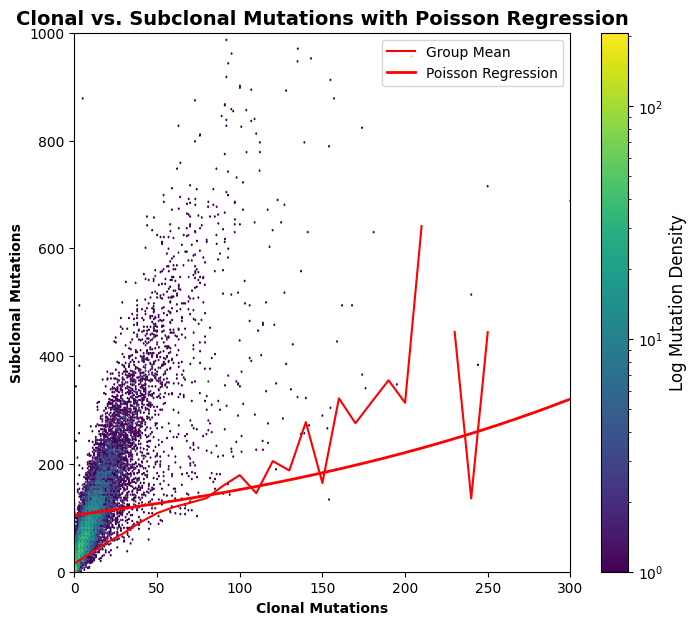

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported

# Generate values for prediction
step = 10  # Step size for x-axis
xlim = 300  # Limit for x-axis
ylim = 1000  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400
x_step = np.arange(0, xlim, step)  # Generate values in steps of 1

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = poisson_model.predict(x_pred)  # Use the corrected matrix

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Group Means
ax.plot(x_step, group_means[0:xlim//step], color="red",  label="Group Mean")

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

## Negative binomial regression

Since the data are over dispersed, we should use a negative binomial regression instead

In [16]:
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")  # Suppress all warnings


# Define the predictor and response variables
x = clonal_summary_left["Clonal Count"]
y = clonal_summary_left["Sub-Clonal Count"]

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
nbinomial_model = sm.NegativeBinomial(y, x_with_const).fit()

# Print the summary of the model
print(nbinomial_model.summary())

Optimization terminated successfully.
         Current function value: 4.038334
         Iterations: 12
         Function evaluations: 22
         Gradient evaluations: 17
                     NegativeBinomial Regression Results                      
Dep. Variable:       Sub-Clonal Count   No. Observations:                20541
Model:               NegativeBinomial   Df Residuals:                    20539
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Mar 2025   Pseudo R-squ.:                 0.09782
Time:                        10:59:36   Log-Likelihood:                -82951.
converged:                       True   LL-Null:                       -91945.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.4627      0.007

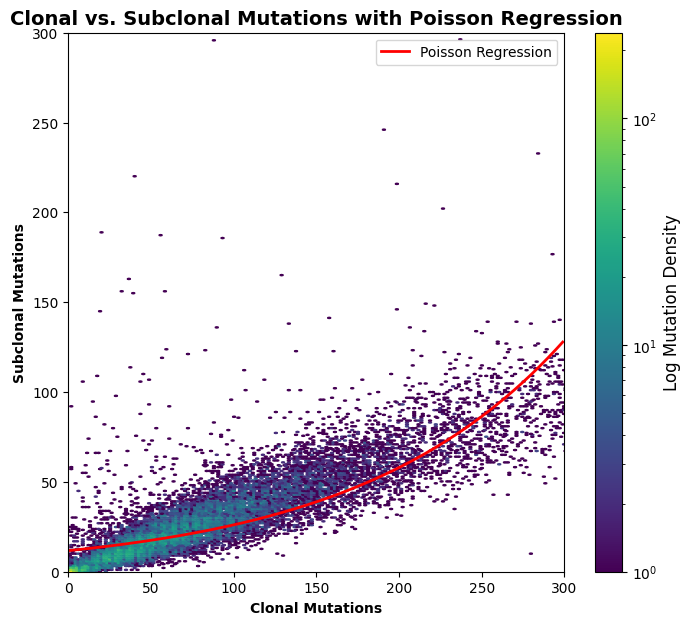

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported

# Generate values for prediction
xlim = 300  # Limit for x-axis
ylim = 300  # Limit for y-axis
x_plot = np.arange(0, xlim)  # Generate 400 values between 0 and 400

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = nbinomial_model.predict(x_pred)  # Use the corrected matrix

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    x, y, 
    gridsize=5000, cmap="viridis", bins='log' ,mincnt=1  # Use log scale for density
)

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, ylim])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

The visualizations below applies methods to filter out outliers for n-D scatter plots, there are not useful for this use case but could be useful later

---

## Appendix

To have a better visualization of regression relationship, I filtered out outliers using seperatly Interquantile Range and Z-Score. 

**IQR**
This method calculates 25th and 75th quantile then preserve only the data within this quantile for x and y 

**Z-Score**
$$ Z = \frac{X-\mu}{\sigma} $$ 
If $|Z| \leq 3$ then it's considered as an outlier. 


NO NEED to filter out the outliers for the regression

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Set R-style theme (ggplot2-like styling)
sns.set_theme(style="whitegrid")  # Equivalent to ggplot2's `theme_minimal()`
plt.style.use("ggplot")  # Ensures a ggplot2-style background

# Compute IQR and Remove Outliers**
def iqr_filter(df, column):
    """Filter data based on IQR range for a given column."""
    Q1, Q3 = np.percentile(df[column], [25, 75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply IQR filtering on both Clonal and Sub-Clonal counts
filtered_data = iqr_filter(clonal_summary, "Clonal Count")
filtered_data = iqr_filter(filtered_data, "Sub-Clonal Count")

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
# sns.histplot(data=filtered_data, x="Clonal Count", y="Sub-Clonal Count", bins=100, ax=ax, cmap="viridis", cbar=True, cbar_kws={"label": "Density"})
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (IQR Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

In [ ]:
from scipy.stats import zscore

# Compute Z-scores
z_scores = np.abs(zscore(clonal_summary[["Clonal Count", "Sub-Clonal Count"]]))

# Set threshold for outliers (e.g., 3 standard deviations)
filtered_data = clonal_summary[(z_scores < 3).all(axis=1)]

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Z-Score Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

In [ ]:
# Extract filtered data
x = clonal_summary["Clonal Count"]
y = clonal_summary["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Generate regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x, y, gridsize=300, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Not Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

Do Poisson tests to the data frame clonal summary